# Ridge Linear Regression: 
### Regularized cost function, closed-form with penalty


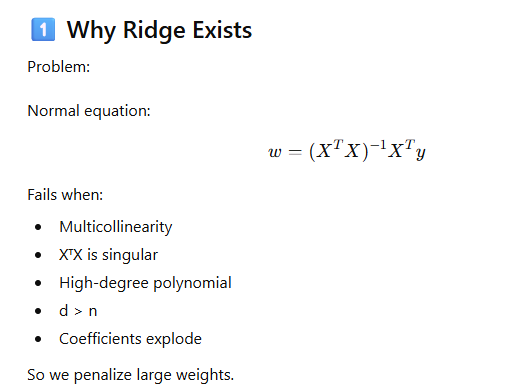

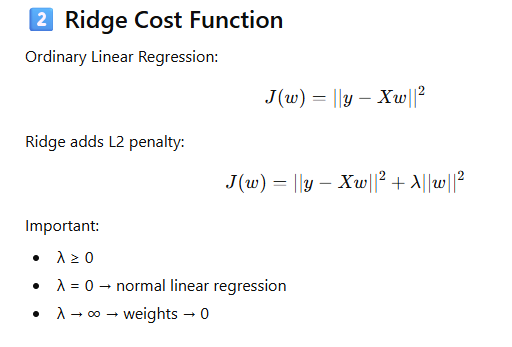

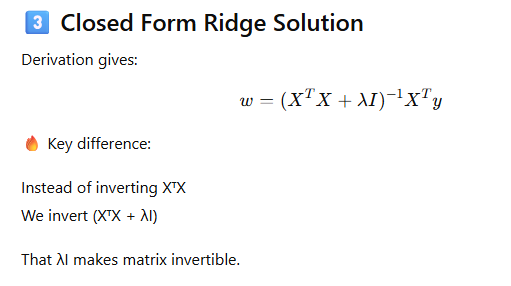

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

X = np.linspace(-3, 3, 50).reshape(-1, 1)
y = 0.5 * X**3 - X**2 + 2*X + 3+ np.random.randn(50, 1)*3

In [3]:
# Polynomial features
def polynomial_features(X, degree):
    n = X.shape[0]
    X_poly = np.ones((n,1))

    for d in range(1, degree+1):
        X_poly = np.hstack((X_poly, X**d))

    return X_poly

In [11]:
# Ridge closed form
def ridge_closed_form(X, y, lambda_):
    """
    Ridge Regression using closed-form solution.

    Parameters:
    X : np.ndarray of shape (m, n)
    y : np.ndarray of shape (m,)
    lambda_ : float (regularization strength)

    Returns:
    w : np.ndarray of shape (n,)
    """
    n_features = X.shape[1]

    I = np.eye(n_features)
    I[0, 0] = 0     #dont regularize the bias
    
    # Closed form solution
    w = np.linalg.inv(X.T @ X + lambda_ * I) @ X.T @ y

    return w

In [5]:
def ridge_closed_form_stable(X, y, lambda_):
    n_features = X.shape[1]
    I = np.eye(n_features)
    I[0, 0] = 0

    return np.linalg.pinv(X.T @ X + lambda_ * I) @ X.T @ y

In [6]:
# Train Model
degree = 15     # High degree to show overfitting

X_poly = polynomial_features(X, degree)

lambda_ = 10

w = ridge_closed_form_stable(X_poly, y, lambda_)

In [7]:
def predict(X, w, degree):
    X_poly = polynomial_features(X, degree)
    return X_poly @ w

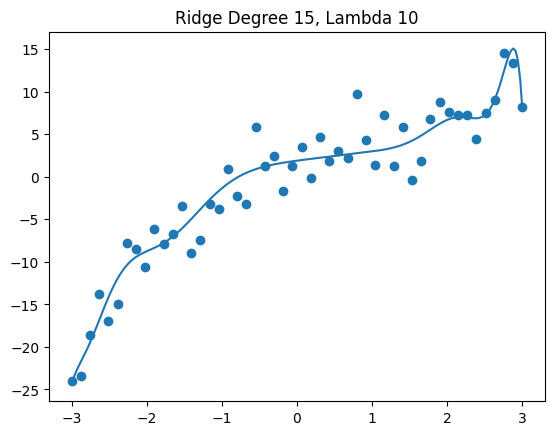

In [9]:
X_test = np.linspace(-3, 3, 200).reshape(-1, 1)
y_pred = predict(X_test, w, degree)

plt.scatter(X, y)
plt.plot(X_test, y_pred)
plt.title(f"Ridge Degree {degree}, Lambda {lambda_}")
plt.show()